# 06 · FastSAM + 배경차분 복수 물체 검출/측정 (실시간)

**모델(FastSAM, YOLO 계열, 클래스 무관) + 보드 지식(배경차분)** 결합.

실험에서 확인한 것:
- FastSAM은 물체를 **깔끔하게 분할**하지만 보드 칸·마커·배경까지 **전부** 분할한다(수십~90개).
- 그래서 '무엇이 물체인지'는 **빈 보드 대비 달라진 영역**(색 무관 배경차분)으로 선별한다.
- → FastSAM 마스크 중 **배경차분 전경과 겹치는 것만** 물체로 채택.

**핵심: 라이브에서 `r`로 같은 각도의 빈 보드를 기준으로 잡아야** 선별이 깨끗하다. (오프라인에서 각도 다른 캘리브 사진을 기준으로 쓰면 지저분하다.)

각 물체: 바닥접점을 보드평면에 역투영해 **중심(mm)·크기(mm)** 산출.

In [1]:
import os, sys, glob
import cv2, numpy as np
import matplotlib.pyplot as plt
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'src'))
import aruco_utils as au, bg_segment as bg, fastsam_detect as fs
print('OpenCV', cv2.__version__)

OUTPUT_DIR = os.path.join(ROOT, 'output')
SCENE_DIR = os.path.join(ROOT, 'data', 'scene_images')
CALIB_DIR = os.path.join(ROOT, 'data', 'calib_images')

SQ = 0.038
board = cv2.aruco.CharucoBoard((5, 7), SQ, SQ*22/30,
                               cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_1000))
K, dist = au.load_intrinsics(os.path.join(OUTPUT_DIR, 'camera_intrinsics.npz'))

CAM_INDEX = 0
model = fs.load_fastsam('FastSAM-s.pt')   # 첫 실행 시 가중치 자동 다운로드
print('FastSAM ready')

OpenCV 4.13.0
Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FastSAM ready


## 정지영상 점검 (구조 확인용)

> 주의: 오프라인 기준을 **각도 다른 캘리브 사진**으로 쓰면 배경차분 전경이 지저분해 선별이 완벽하지 않다. 깨끗한 결과는 아래 **실시간(`r`)** 에서 확인. 같은 각도의 빈 보드 raw가 있으면 그걸 기준으로 넣자.

기준: WIN_20260705_00_35_37_Pro.jpg
대상: snap_raw_000.png
검출 물체: 18
  #0 center (1, 237)mm size (24, 6)mm
  #1 center (41, 178)mm size (53, 2)mm
  #2 center (130, 152)mm size (24, 9)mm
  #3 center (114, 86)mm size (16, 13)mm
  #4 center (41, 19)mm size (33, 3)mm
  #5 center (5, 56)mm size (27, 3)mm
  #6 center (6, 130)mm size (24, 4)mm
  #7 center (6, 204)mm size (22, 4)mm
  #8 center (153, 239)mm size (31, 5)mm
  #9 center (44, 241)mm size (25, 4)mm
  #10 center (70, 101)mm size (31, 1)mm
  #11 center (117, 237)mm size (16, 5)mm
  #12 center (119, 21)mm size (28, 1)mm
  #13 center (157, 132)mm size (28, 2)mm
  #14 center (157, 54)mm size (23, 2)mm
  #15 center (61, 167)mm size (29, 1)mm
  #16 center (86, 207)mm size (9, 2)mm
  #17 center (67, 146)mm size (14, 1)mm


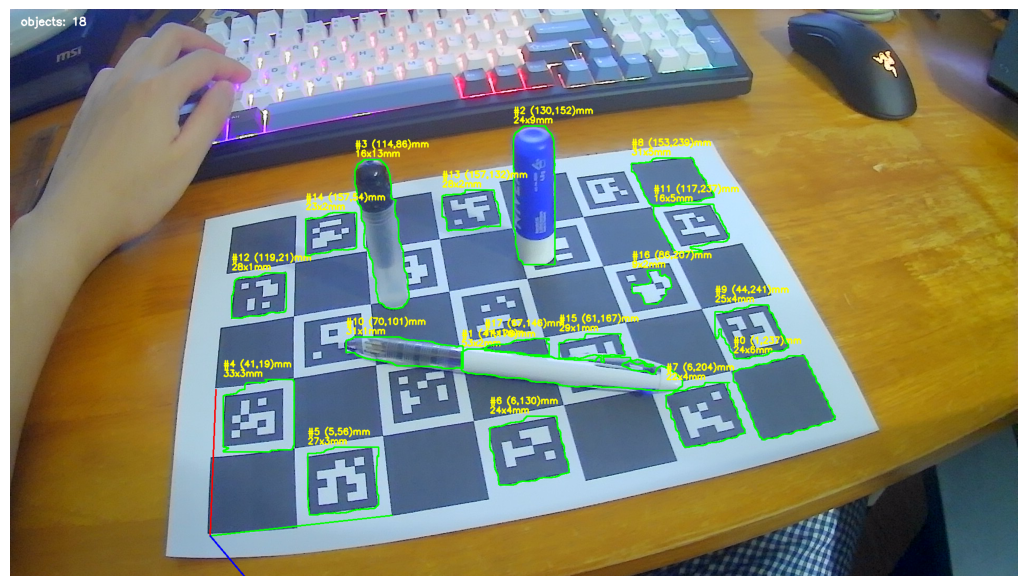

In [2]:
# 기준(빈 보드): 같은 각도 raw가 있으면 우선, 없으면 캘리브 사진(부정확)
ref_cands = sorted(glob.glob(os.path.join(SCENE_DIR, 'empty_*.png'))) or \
            sorted(glob.glob(os.path.join(OUTPUT_DIR, 'ref_*.png'))) or \
            sorted(glob.glob(os.path.join(CALIB_DIR, '*.jpg')))
empty = cv2.imread(ref_cands[0]); print('기준:', os.path.basename(ref_cands[0]))
ref = bg.make_reference_canonical(empty, board, K, dist, SQ)

tgt_cands = sorted(glob.glob(os.path.join(OUTPUT_DIR, 'snap_raw_*.png'))) or \
            sorted(glob.glob(os.path.join(SCENE_DIR, '*.*')))
tgt = cv2.imread(tgt_cands[0]); print('대상:', os.path.basename(tgt_cands[0]))

det = fs.detect_objects_fastsam(tgt, model, board, K, dist, ref, SQ,
                                imgsz=1024, thresh=45, shrink=25)
print('검출 물체:', 0 if det is None else len(det['objects']))
if det:
    for i, o in enumerate(det['objects']):
        print(f"  #{i} center {tuple(round(v) for v in o['center_mm'])}mm size {tuple(round(v) for v in o['size_mm'])}mm")
    vis = fs.draw_fastsam(tgt, det, K, dist, SQ)
    plt.figure(figsize=(13, 8)); plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

## 실시간 실행 (핵심)

**순서:** ① 보드만 두고 실행 → **`r`** (빈 보드 기준 설정) → ② 물체들을 올리면 FastSAM+배경차분으로 검출.
- **`r`**: 현재(빈 보드) 프레임 기준 설정/갱신 (조명·각도 바뀌면 다시)
- **`s`**: 스냅(raw+vis)  ·  **`q`**: 종료

> 실시간은 `imgsz=640` 권장(속도). 잔검출이 많으면 `overlap_thresh`↑, `min_area_px`↑.

In [3]:
fs.run_live_fastsam(K, dist, board, SQ, model=model, cam_index=CAM_INDEX,
                    imgsz=640, snapshot_dir=OUTPUT_DIR,
                    thresh=45, shrink=25, overlap_thresh=0.30, min_area_px=1000)
print('종료됨')

reference set
snapshot 0
종료됨


## 관찰 & 다음

- **잔검출(보드 조각) 많음**: 기준을 `r`로 다시(같은 각도) 잡기, `overlap_thresh`↑, `min_area_px`↑.
- **물체를 놓침**: `thresh`(배경차분)↓, 물체를 보드 안쪽에.
- **속도**: `imgsz`를 512~640으로. GTX1660에서 FastSAM-s는 실시간권.
- 다음: 물체 ID/추적(프레임 간 매칭), 높이까지(02 수직모서리 결합), 가상 3D 씬 실시간 반영.